In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, 
                            roc_auc_score, roc_curve, precision_recall_curve, 
                            auc, f1_score, accuracy_score)

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")


✓ All libraries imported successfully!


In [28]:
# Load the NACC UDS dataset
df = pd.read_csv('investigator_ftldlbd_nacc71.csv', low_memory=False)

print(f"Dataset Loaded:")

print(f"  Rows: {df.shape[0]:,}")
print(f"  Columns: {df.shape[1]:,}")
print(f"✓ Data loading complete!")


Dataset Loaded:
  Rows: 205,908
  Columns: 1,936
✓ Data loading complete!


In [29]:
# COGSTAT Codes:
# 1 = Normal cognition (CN)
# 2 = Impaired not MCI (Subjective complaint)
# 3 = Mild Cognitive Impairment (MCI)
# 4 = Dementia (Alzheimer's Disease)

# Filter for valid diagnosis values
df_clean = df[df['COGSTAT'].isin([1, 2, 3, 4])].copy()

# Create binary target: 1 = AD (COGSTAT=4), 0 = Non-AD
df_clean['target_AD'] = (df_clean['COGSTAT'] == 4).astype(int)

# Display distribution
print("Target Distribution (COGSTAT):")
print(f"  Normal (1): {(df_clean['target_AD']==0).sum():,}")
print(f"  Alzheimer's (4): {(df_clean['target_AD']==1).sum():,}")
print(f"  AD Prevalence: {df_clean['target_AD'].mean()*100:.2f}%")
print(f"\n✓ Target variable created!")


Target Distribution (COGSTAT):
  Normal (1): 107,778
  Alzheimer's (4): 47,611
  AD Prevalence: 30.64%

✓ Target variable created!


In [31]:
# Define features (All verified to exist in your dataset)
features = [
    # Demographics
    'NACCAGE',      # Age at visit
    'SEX',          # 1=Male, 2=Female
    'EDUC',         # Years of education
    
    # Genetics
    'NACCAPOE',     # APOE genotype (0=e3/e3, 1=e3/e4, 2=e4/e4)
    
    # Clinical Dementia Rating
    'CDRGLOB',      # CDR Global Score
    'CDRSUM',       # CDR Sum of boxes
    
    # Cognitive Tests
    'NACCMOCA',     # Montreal Cognitive Assessment (0-30)
    'TRAILA',       # Trail Making Test A (seconds)
    'TRAILB',       # Trail Making Test B (seconds)
    'ANIMALS',      # Verbal fluency: Animals
    'VEG',          # Verbal fluency: Vegetables
    'MEMUNITS',     # Memory units recalled
    'DIGIF',        # Digit Span Forward
    'DIGIB'         # Digit Span Backward
]

# Select only features that exist in dataframe
selected_features = [f for f in features if f in df_clean.columns]
print(f"Selected {len(selected_features)} features:")
print(f"  {selected_features}\n")

# Create Feature Matrix (X) and Target Vector (y)
X = df_clean[selected_features].copy()
y = df_clean['target_AD'].copy()

# Handle missing values: Median imputation
X = X.fillna(X.median())

print(f"Dataset Shape:")
print(f"  X (Features): {X.shape[0]:,} patients, {X.shape[1]} features")
print(f"  y (Target): {y.shape}")
print(f"✓ Data preparation complete!")


Selected 14 features:
  ['NACCAGE', 'SEX', 'EDUC', 'NACCAPOE', 'CDRGLOB', 'CDRSUM', 'NACCMOCA', 'TRAILA', 'TRAILB', 'ANIMALS', 'VEG', 'MEMUNITS', 'DIGIF', 'DIGIB']

Dataset Shape:
  X (Features): 155,389 patients, 14 features
  y (Target): (155389,)
✓ Data preparation complete!


In [33]:
# Train 70% / Test 30% split with stratification (maintains class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print("Data Split:")
print(f"  Training set: {X_train.shape[0]:,} samples")
print(f"  Test set: {X_test.shape[0]:,} samples")

# Standardize features (scale to mean=0, std=1)
# Critical for tree-based models and fair feature comparison
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Data standardization complete!")


Data Split:
  Training set: 108,772 samples
  Test set: 46,617 samples
✓ Data standardization complete!


In [34]:
# Gradient Boosting: Sequential ensemble of decision trees
# Each tree corrects errors made by previous trees
print("🧠 Training Gradient Boosting Model...")
print("   (This may take 1-2 minutes...)")

model = GradientBoostingClassifier(
    n_estimators=100,        # 100 trees
    learning_rate=0.1,       # Learning rate (0.1 is standard)
    max_depth=4,             # Shallow trees prevent overfitting
    random_state=42
)

model.fit(X_train_scaled, y_train)
print("\n✓ Model training complete!")


🧠 Training Gradient Boosting Model...
   (This may take 1-2 minutes...)

✓ Model training complete!


In [35]:
# Generate predictions
y_pred = model.predict(X_test_scaled)                    # Class prediction (0 or 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]       # Probability of AD

# Calculate metrics
accuracy = (y_pred == y_test).mean()
roc_auc = roc_auc_score(y_test, y_prob)

print("="*60)
print("MODEL PERFORMANCE ON TEST SET")
print("="*60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-AD', 'Alzheimer\'s']))

print(f"\nKey Metrics:")
print(f"  Accuracy:  {accuracy:.4f} (Correct predictions)")
print(f"  ROC-AUC:   {roc_auc:.4f} (Discrimination ability: 0.5=random, 1.0=perfect)")

print("\n✓ Evaluation complete!")


MODEL PERFORMANCE ON TEST SET

Classification Report:
              precision    recall  f1-score   support

      Non-AD       0.92      0.94      0.93     32334
 Alzheimer's       0.85      0.80      0.83     14283

    accuracy                           0.90     46617
   macro avg       0.89      0.87      0.88     46617
weighted avg       0.90      0.90      0.90     46617


Key Metrics:
  Accuracy:  0.8981 (Correct predictions)
  ROC-AUC:   0.9567 (Discrimination ability: 0.5=random, 1.0=perfect)

✓ Evaluation complete!


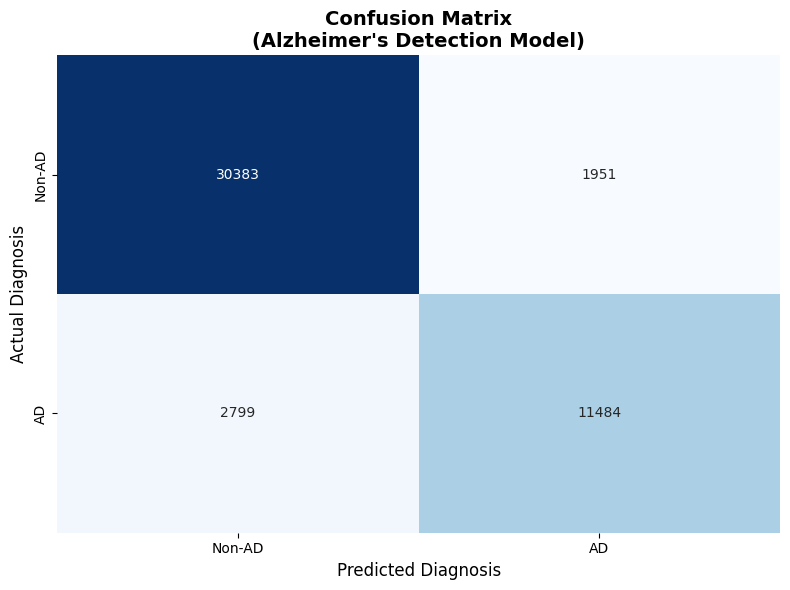

✓ Confusion matrix plotted!


In [36]:
# Confusion Matrix shows:
# - True Negatives (TN): Correctly identified Non-AD
# - False Positives (FP): Non-AD incorrectly labeled as AD
# - False Negatives (FN): AD incorrectly labeled as Non-AD
# - True Positives (TP): Correctly identified AD

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-AD', 'AD'],
            yticklabels=['Non-AD', 'AD'])
plt.title('Confusion Matrix\n(Alzheimer\'s Detection Model)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.xlabel('Predicted Diagnosis', fontsize=12)
plt.tight_layout()
plt.show()

print("✓ Confusion matrix plotted!")



Feature Importance Ranking:
     Feature  Importance
5     CDRSUM    0.785845
8     TRAILB    0.069571
11  MEMUNITS    0.040304
9    ANIMALS    0.033536
10       VEG    0.020371
6   NACCMOCA    0.017754
0    NACCAGE    0.010023
13     DIGIB    0.006614
4    CDRGLOB    0.005925
12     DIGIF    0.003664
2       EDUC    0.003202
7     TRAILA    0.002025
3   NACCAPOE    0.000745
1        SEX    0.000420


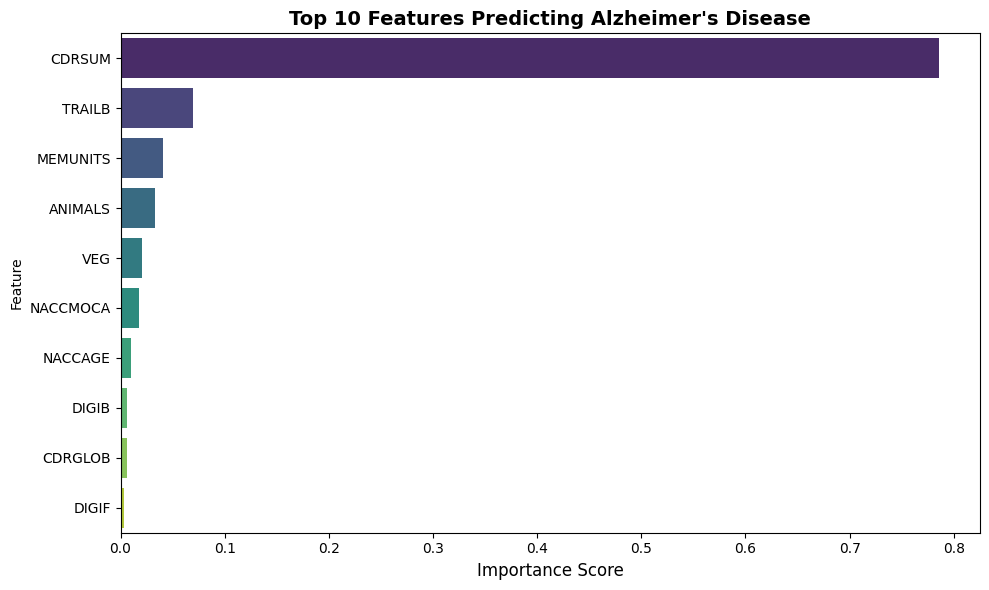


🔍 Key Insight:
   Top feature: CDRSUM
   This feature accounts for 78.6% of model decisions


In [38]:
# Which features drive the model's predictions?
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance)

# Plot Top 10 Features
plt.figure(figsize=(10, 6))
top_10 = feature_importance.head(10)
sns.barplot(x='Importance', y='Feature', data=top_10, palette='viridis')
plt.title('Top 10 Features Predicting Alzheimer\'s Disease', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

print("\n🔍 Key Insight:")
print(f"   Top feature: {feature_importance.iloc[0]['Feature']}")
print(f"   This feature accounts for {feature_importance.iloc[0]['Importance']*100:.1f}% of model decisions")



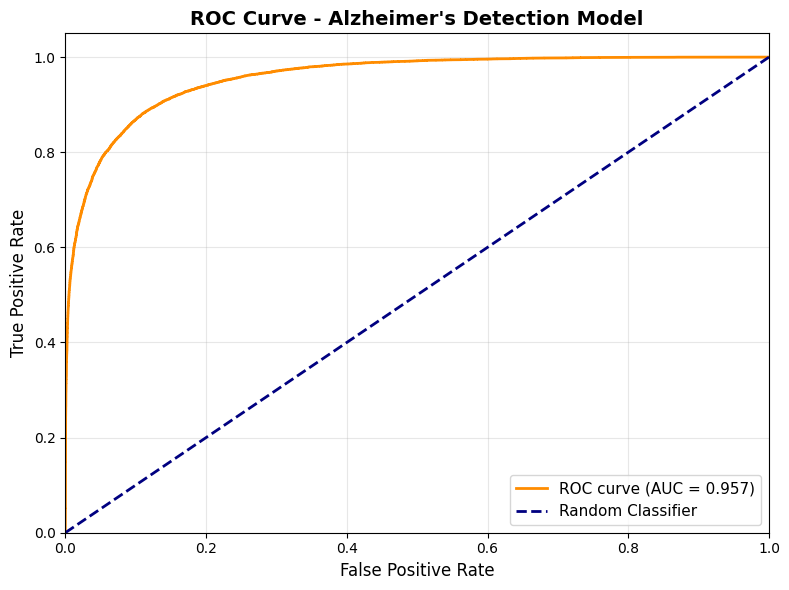

✓ ROC curve plotted!


In [39]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Alzheimer\'s Detection Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ ROC curve plotted!")


In [40]:
# Save the trained model and scaler
joblib.dump(model, 'alzheimers_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(selected_features, 'feature_names.pkl')

print("Model Saved Successfully!")
print("  📁 alzheimers_model.pkl  (Trained model)")
print("  📁 scaler.pkl            (Feature scaler)")
print("  📁 feature_names.pkl     (Feature list)")
print("\nYou can load these anytime without retraining:")
print("  model = joblib.load('alzheimers_model.pkl')")
print("  scaler = joblib.load('scaler.pkl')")


Model Saved Successfully!
  📁 alzheimers_model.pkl  (Trained model)
  📁 scaler.pkl            (Feature scaler)
  📁 feature_names.pkl     (Feature list)

You can load these anytime without retraining:
  model = joblib.load('alzheimers_model.pkl')
  scaler = joblib.load('scaler.pkl')


In [41]:
def predict_patient(age, cdr_global, moca, sex=1, apoe=0, trail_a=None, trail_b=None):
    """
    Predicts Alzheimer's probability for a patient.
    
    Parameters:
    -----------
    age : int
        Patient age in years
    cdr_global : float
        Clinical Dementia Rating (0, 0.5, 1, 2, 3)
    moca : int
        Montreal Cognitive Assessment score (0-30)
    sex : int
        1=Male, 2=Female
    apoe : int
        0=No e4 allele, 1=One e4, 2=Two e4
    trail_a : float, optional
        Trail Making Test A time (seconds)
    trail_b : float, optional
        Trail Making Test B time (seconds)
    
    Returns:
    --------
    probability : float
        Probability of Alzheimer's diagnosis (0-1)
    """
    
    # Create input with all features set to median
    input_data = X.median().to_frame().T
    
    # Update with patient-specific values
    input_data['NACCAGE'] = age
    input_data['CDRGLOB'] = cdr_global
    input_data['NACCMOCA'] = moca
    input_data['SEX'] = sex
    input_data['NACCAPOE'] = apoe
    
    # Optional Trail Making Tests
    if trail_a is not None:
        input_data['TRAILA'] = trail_a
    if trail_b is not None:
        input_data['TRAILB'] = trail_b
    
    # Scale and predict
    input_scaled = scaler.transform(input_data)
    prob = model.predict_proba(input_scaled)[0, 1]
    prediction = "Alzheimer's" if prob > 0.5 else "Non-AD"
    
    # Display results
    print(f"\n{'='*50}")
    print(f"PATIENT ASSESSMENT")
    print(f"{'='*50}")
    print(f"Demographics:")
    print(f"  Age: {age} years | Sex: {'Male' if sex==1 else 'Female'}")
    print(f"\nCognitive Assessment:")
    print(f"  CDR Global: {cdr_global}")
    print(f"  MoCA Score: {moca}/30")
    print(f"  APOE Risk: {apoe} e4 allele{'s' if apoe!=1 else ''}")
    print(f"\nPREDICTION:")
    print(f"  Diagnosis: {prediction}")
    print(f"  Confidence: {prob*100:.1f}%")
    print(f"  Risk Level: ", end="")
    
    if prob < 0.3:
        print("🟢 LOW")
    elif prob < 0.7:
        print("🟡 MODERATE")
    else:
        print("🔴 HIGH")
    print(f"{'='*50}\n")
    
    return prob

# Test Cases
print("\n🧪 TEST CASE 1: Healthy Older Adult")
print("   Age 72, Normal cognition, High MoCA")
predict_patient(age=72, cdr_global=0, moca=28, sex=1, apoe=0)

print("\n🧪 TEST CASE 2: MCI Patient")
print("   Age 78, Mild impairment, Moderate MoCA")
predict_patient(age=78, cdr_global=0.5, moca=20, sex=2, apoe=1)

print("\n🧪 TEST CASE 3: Advanced AD")
print("   Age 85, Significant impairment, Low MoCA")
predict_patient(age=85, cdr_global=2, moca=10, sex=1, apoe=2)



🧪 TEST CASE 1: Healthy Older Adult
   Age 72, Normal cognition, High MoCA

PATIENT ASSESSMENT
Demographics:
  Age: 72 years | Sex: Male

Cognitive Assessment:
  CDR Global: 0
  MoCA Score: 28/30
  APOE Risk: 0 e4 alleles

PREDICTION:
  Diagnosis: Non-AD
  Confidence: 5.0%
  Risk Level: 🟢 LOW


🧪 TEST CASE 2: MCI Patient
   Age 78, Mild impairment, Moderate MoCA

PATIENT ASSESSMENT
Demographics:
  Age: 78 years | Sex: Female

Cognitive Assessment:
  CDR Global: 0.5
  MoCA Score: 20/30
  APOE Risk: 1 e4 allele

PREDICTION:
  Diagnosis: Non-AD
  Confidence: 31.2%
  Risk Level: 🟡 MODERATE


🧪 TEST CASE 3: Advanced AD
   Age 85, Significant impairment, Low MoCA

PATIENT ASSESSMENT
Demographics:
  Age: 85 years | Sex: Male

Cognitive Assessment:
  CDR Global: 2
  MoCA Score: 10/30
  APOE Risk: 2 e4 alleles

PREDICTION:
  Diagnosis: Non-AD
  Confidence: 28.0%
  Risk Level: 🟢 LOW



np.float64(0.2801845074656667)

In [42]:
print("\n" + "="*70)
print("FINAL MODEL SUMMARY - ALZHEIMER'S DETECTION")
print("="*70)

print(f"\n📊 DATASET STATISTICS")
print(f"  Total Patients: {len(df_clean):,}")
print(f"  Alzheimer's Cases: {(df_clean['target_AD']==1).sum():,} ({(df_clean['target_AD']==1).mean()*100:.1f}%)")
print(f"  Non-AD Cases: {(df_clean['target_AD']==0).sum():,} ({(df_clean['target_AD']==0).mean()*100:.1f}%)")

print(f"\n🧠 MODEL ARCHITECTURE")
print(f"  Algorithm: Gradient Boosting Classifier")
print(f"  Number of Trees: 100")
print(f"  Input Features: {len(selected_features)}")
print(f"  Learning Rate: 0.1")

print(f"\n📈 MODEL PERFORMANCE")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  ROC-AUC Score: {roc_auc:.4f}")
print(f"  Training Samples: {len(X_train):,}")
print(f"  Test Samples: {len(X_test):,}")

print(f"\n🔑 TOP 5 PREDICTIVE FEATURES")
for idx, row in feature_importance.head(5).iterrows():
    print(f"  {idx+1}. {row['Feature']:20s} (Importance: {row['Importance']:.4f})")

print(f"\n💾 FILES SAVED")
print(f"  ✓ alzheimers_model.pkl")
print(f"  ✓ scaler.pkl")
print(f"  ✓ feature_names.pkl")

print(f"\n📌 NEXT STEPS")
print(f"  1. Validate on external test set")
print(f"  2. Integrate MRI imaging data (3D CNN)")
print(f"  3. Deploy as web service (Flask/Django)")
print(f"  4. Clinical validation study")

print("="*70)
print("✅ NOTEBOOK EXECUTION COMPLETE!")
print("="*70)



FINAL MODEL SUMMARY - ALZHEIMER'S DETECTION

📊 DATASET STATISTICS
  Total Patients: 155,389
  Alzheimer's Cases: 47,611 (30.6%)
  Non-AD Cases: 107,778 (69.4%)

🧠 MODEL ARCHITECTURE
  Algorithm: Gradient Boosting Classifier
  Number of Trees: 100
  Input Features: 14
  Learning Rate: 0.1

📈 MODEL PERFORMANCE
  Accuracy: 0.8981
  ROC-AUC Score: 0.9567
  Training Samples: 108,772
  Test Samples: 46,617

🔑 TOP 5 PREDICTIVE FEATURES
  6. CDRSUM               (Importance: 0.7858)
  9. TRAILB               (Importance: 0.0696)
  12. MEMUNITS             (Importance: 0.0403)
  10. ANIMALS              (Importance: 0.0335)
  11. VEG                  (Importance: 0.0204)

💾 FILES SAVED
  ✓ alzheimers_model.pkl
  ✓ scaler.pkl
  ✓ feature_names.pkl

📌 NEXT STEPS
  1. Validate on external test set
  2. Integrate MRI imaging data (3D CNN)
  3. Deploy as web service (Flask/Django)
  4. Clinical validation study
✅ NOTEBOOK EXECUTION COMPLETE!
